Redes neuronales enfocadas al reconocimiento de imagenes. 

In [1]:
########################################################################
#########################CIFAR-10 Dataset using CNNs####################
########################################################################

Redes neuronales no supervisadas enfocadas al reconocimiento de imagenes.

In [2]:
from keras.datasets import cifar10

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
import tensorflow as tf
import numpy as np

In [5]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPool2D
from keras.utils import to_categorical

In [6]:
# to calculate accuracy
from sklearn.metrics import accuracy_score
from keras.layers import Dense, Activation, Flatten

In [7]:
# loading the dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

In [8]:
#Dimension of training set
X_train.shape

(50000, 32, 32, 3)

In [9]:
display(X_train[1])

array([[[154, 177, 187],
        [126, 137, 136],
        [105, 104,  95],
        ...,
        [ 91,  95,  71],
        [ 87,  90,  71],
        [ 79,  81,  70]],

       [[140, 160, 169],
        [145, 153, 154],
        [125, 125, 118],
        ...,
        [ 96,  99,  78],
        [ 77,  80,  62],
        [ 71,  73,  61]],

       [[140, 155, 164],
        [139, 146, 149],
        [115, 115, 112],
        ...,
        [ 79,  82,  64],
        [ 68,  70,  55],
        [ 67,  69,  55]],

       ...,

       [[175, 167, 166],
        [156, 154, 160],
        [154, 160, 170],
        ...,
        [ 42,  34,  36],
        [ 61,  53,  57],
        [ 93,  83,  91]],

       [[165, 154, 128],
        [156, 152, 130],
        [159, 161, 142],
        ...,
        [103,  93,  96],
        [123, 114, 120],
        [131, 121, 131]],

       [[163, 148, 120],
        [158, 148, 122],
        [163, 156, 133],
        ...,
        [143, 133, 139],
        [143, 134, 142],
        [143, 133, 144]]

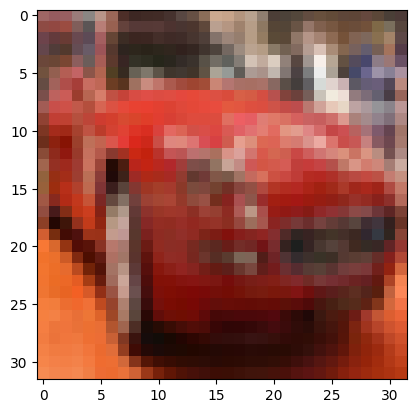

In [10]:
#See some images of the data set
plt.imshow(X_train[5])

In [11]:
display(y_train)

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [12]:
# # building the input vector from the 32x32 pixels
X_train = X_train.reshape(X_train.shape[0], 32, 32, 3)
X_test = X_test.reshape(X_test.shape[0], 32, 32, 3)
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

In [13]:
# normalizing the data to help with the training
X_train /= 255
X_test /= 255

In [14]:
# one-hot encoding using keras' numpy-related utilities
n_classes = 10
print("Shape before one-hot encoding: ", y_train.shape)
Y_train = to_categorical(y_train, n_classes)
Y_test = to_categorical(y_test, n_classes)
print("Shape after one-hot encoding: ", Y_train.shape)

Shape before one-hot encoding:  (50000, 1)
Shape after one-hot encoding:  (50000, 10)


In [15]:
from keras.layers import BatchNormalization, RandomFlip, RandomRotation, RandomTranslation

model = Sequential()

# Data Augmentation integrado al modelo
model.add(RandomFlip("horizontal", input_shape=(32,32,3)))
model.add(RandomRotation(0.1))
model.add(RandomTranslation(0.1, 0.1))

# Bloque 1
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Bloque 2
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Bloque 3
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Clasificador
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
from keras.optimizers import Adam
from keras.callbacks import ReduceLROnPlateau

# Reduce el learning rate si la val_loss no mejora
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

model.compile(loss='categorical_crossentropy',
              metrics=['accuracy'],
              optimizer=Adam(learning_rate=0.001))

history = model.fit(X_train, Y_train,
                    batch_size=64,
                    epochs=10,
                    validation_data=(X_test, Y_test),
                    callbacks=[reduce_lr])

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 223s 276ms/step - accuracy: 0.3715 - loss: 1.8428 - val_accuracy: 0.4661 - val_loss: 1.4742 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 210s 268ms/step - accuracy: 0.4925 - loss: 1.4050 - val_accuracy: 0.5309 - val_loss: 1.3396 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 211s 270ms/step - accuracy: 0.5471 - loss: 1.2694 - val_accuracy: 0.5023 - val_loss: 1.4463 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 316s 404ms/step - accuracy: 0.5803 - loss: 1.1838 - val_accuracy: 0.5885 - val_loss: 1.2560 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 307s 393ms/step - accuracy: 0.6047 - loss: 1.1149 - val_accuracy: 0.6417 - val_loss: 1.0266 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 245s 313ms/step - accuracy: 0.6245 - loss: 1.0677 - val_accuracy: 0.6501 - val_loss: 1.0123 - learning_rate: 0.0010
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 208s 266ms/step - accura

In [17]:
import numpy as np

best_acc = np.max(history.history['accuracy'])
best_val_acc = np.max(history.history['val_accuracy'])
best_loss = np.min(history.history['loss'])
best_val_loss = np.min(history.history['val_loss'])

print(f"Best Training Accuracy: {best_acc:.4f}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Lowest Training Loss: {best_loss:.4f}")
print(f"Lowest Validation Loss: {best_val_loss:.4f}")


Best Training Accuracy: 0.6723
Best Validation Accuracy: 0.6861
Lowest Training Loss: 0.9390
Lowest Validation Loss: 0.9182


Se completo el codigo para CNN cambiando el numero de pixels por $32 \times 32 \times 3$ para que pueda ingresar a la red neuronal. Se utilizo la misma red neuornal implementada en clase con la misma tasa de aprendizaje y función de costos. La modificacion que se añadio a la etapa de entrenamiento es el numero de epocas, aumentando a 20 epocas comparadas con las 10 epocas de la clase. 